
# Day 13 — NIFTY 50 High Price Prediction (Assignment Submission)

**Scope:**
- **Target:** `High`
- **Windows:** 30, 60, 90 days
- **Models:** KNN (ML) + RNN, GRU, LSTM, Bidirectional LSTM (DL)
- **Epochs (DL):** 50
- **Metrics:** MAE, RMSE

This notebook is the **clean submission**. It uses a consistent folder layout and the 3‑mode `fetch.py` script.



## 0. Paths & Data Fetch (one-time)

You can fetch the dataset with any of the three modes. The recommended command is the **nifty** (Kaggle dataset) mode:

```bash
# from repo root
python ../src/fetch.py --kaggle ashishjangra27/nifty-50-25-yrs-data --dest ../data
```

Alternatively:
```bash
# dataset by owner/name
python ../src/fetch.py --kaggle ashishjangra27/nifty-50-25-yrs-data --dest ../data

# or direct URL(s)
python ../src/fetch.py --url https://example.com/nifty.csv --dest ../data
```


In [1]:

# 1. Imports
import os, sys, math, json, warnings
import numpy as np
import pandas as pd
from copy import deepcopy
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Optional: Keras for DL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional


In [4]:

# 2. Configuration
ASSIGN_TARGET = "High"
ASSIGN_WINDOWS = [30, 60, 90]

TEST_SIZE = 0.10
RANDOM_STATE = 42

DL_EPOCHS = 50
DL_BATCH = 8
DL_VERBOSE = 0

# Paths (adjust if needed)
PROJECT_ROOT = ".."
DATA_RAW = os.path.join(PROJECT_ROOT, "data")
ART_RESULTS = os.path.join(PROJECT_ROOT, "snippets","artifacts", "results")
ART_MODELS_ML = os.path.join(PROJECT_ROOT, "snippets","artifacts", "models", "ml")
ART_MODELS_DL = os.path.join(PROJECT_ROOT, "snippets","artifacts", "models", "dl")
ART_FIGS = os.path.join(PROJECT_ROOT, "snippets","artifacts", "figures")

for d in [DATA_RAW, ART_RESULTS, ART_MODELS_ML, ART_MODELS_DL, ART_FIGS]:
    os.makedirs(d, exist_ok=True)

print("Folders ready:", DATA_RAW)


Folders ready: ..\data


In [5]:

# 3. Load data
# Expect a CSV in DATA_RAW. If there are many, pick the first *.csv.
csv_candidates = [f for f in os.listdir(DATA_RAW) if f.lower().endswith(".csv")]
if not csv_candidates:
    raise FileNotFoundError(f"No CSV found in {DATA_RAW}. Run fetch.py first.")
csv_path = os.path.join(DATA_RAW, csv_candidates[0])
print("Reading:", csv_path)

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()


Reading: ..\data\data.csv
Shape: (6315, 5)


,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.2
1,2000-01-04,1594.40,1641.95,1594.40,1638.7
2,2000-01-05,1634.55,1635.50,1555.05,1595.8
3,2000-01-06,1595.80,1639.00,1595.80,1617.6
4,2000-01-07,1616.60,1628.25,1597.20,1613.3


In [6]:

# 4. Build supervised windows for target=High and windows=30/60/90

def return_pairs(series: pd.Series, days: int):
    vals = series.to_numpy().astype(float)
    X, y = [], []
    for i in range(len(vals) - days):
        X.append(vals[i:i+days])
        y.append(vals[i+days])
    return np.array(X), np.array(y)

chunked_data = {}
for d in ASSIGN_WINDOWS:
    X, y = return_pairs(df[ASSIGN_TARGET], d)
    chunked_data[f"X_{ASSIGN_TARGET}_{d}"] = X
    chunked_data[f"y_{ASSIGN_TARGET}_{d}"] = y

chunk_pairs = []
for k in chunked_data:
    if k.startswith("X_"):
        yk = k.replace("X_", "y_")
        if yk in chunked_data:
            chunk_pairs.append([k, yk])

print("Pairs:", len(chunk_pairs), chunk_pairs[:3])


Pairs: 3 [['X_High_30', 'y_High_30'], ['X_High_60', 'y_High_60'], ['X_High_90', 'y_High_90']]


In [7]:

# 5. DL model builders
def build_rnn(input_shape):
    model = Sequential([SimpleRNN(50, activation='tanh', input_shape=input_shape),
                        Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([LSTM(50, activation='tanh', input_shape=input_shape),
                        Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([GRU(50, activation='tanh', input_shape=input_shape),
                        Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([Bidirectional(LSTM(50, activation='tanh'), input_shape=input_shape),
                        Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    return model

dl_models = {
    "RNN": build_rnn,
    "GRU": build_gru,
    "LSTM": build_lstm,
    "Bidirectional_LSTM": build_bilstm,
}


In [10]:
import os
from tensorflow.keras.callbacks import BackupAndRestore, ModelCheckpoint, CSVLogger, EarlyStopping

CKPT_ROOT = "artifacts/checkpoints"
LOGS_ROOT = "artifacts/logs"
os.makedirs(CKPT_ROOT, exist_ok=True)
os.makedirs(LOGS_ROOT, exist_ok=True)

def make_callbacks(model_name: str, window: int):
    run_id = f"{model_name}_High_{window}"
    backup_dir = os.path.join(CKPT_ROOT, run_id, "backup")  # used by BackupAndRestore
    best_path  = os.path.join(CKPT_ROOT, run_id, f"best_{run_id}.weights.h5")
    log_path   = os.path.join(LOGS_ROOT, f"{run_id}.csv")

    return [
        # 1) Auto-resume (saves optimizer state + epoch, resumes where it left off)
        BackupAndRestore(backup_dir=backup_dir, delete_checkpoint=False),

        # 2) Persist best weights
        ModelCheckpoint(best_path, monitor="val_loss", save_best_only=True,
                        save_weights_only=True, verbose=1),

        # 3) Training log (so you can plot later)
        CSVLogger(log_path, append=True),

        # 4) Optional early stopping (speeds things up if val stops improving)
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ]

In [16]:

# 6. Training (KNN + DL@50 epochs) across windows

trained_models = {}

for Xk, Yk in tqdm(chunk_pairs):
    X = chunked_data[Xk]
    y = chunked_data[Yk]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # --- KNN (ML) ---
    knn = KNeighborsRegressor()
    knn.fit(X_train, y_train)
    y_tr = knn.predict(X_train)
    y_te = knn.predict(X_test)

    key = f"KNN_{Xk[2:]}"  # e.g., KNN_High_30
    trained_models[key] = {
        "model": knn,
        "train_mae": float(mean_absolute_error(y_train, y_tr)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, y_tr))),
        "test_mae": float(mean_absolute_error(y_test, y_te)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_te))),
    }

    # --- DL models with auto-resume & checkpoints ---
    X_train_rnn = np.expand_dims(X_train, -1)
    X_test_rnn  = np.expand_dims(X_test, -1)
    input_shape = (X_train.shape[1], 1)
    window = int(Xk.split("_")[-1])

    for model_name, builder in dl_models.items():
        model = builder(input_shape)

        # Callbacks enable pause/resume and best-weight saving
        callbacks = make_callbacks(model_name, window)

        # NOTE: No need to manage initial_epoch; BackupAndRestore handles resume automatically
        history = model.fit(
            X_train_rnn, y_train,
            validation_split=0.10,          # enables EarlyStopping/ModelCheckpoint to use val_loss
            epochs=DL_EPOCHS, batch_size=DL_BATCH, verbose=DL_VERBOSE,
            callbacks=callbacks,
        )

        # Evaluate with the (restored) best weights
        y_tr = model.predict(X_train_rnn, verbose=0).flatten()
        y_te = model.predict(X_test_rnn,  verbose=0).flatten()

        key = f"{model_name}_{Xk[2:]}"  # e.g., LSTM_High_60
        trained_models[key] = {
            "model": model,
            "train_mae": float(mean_absolute_error(y_train, y_tr)),
            "train_rmse": float(np.sqrt(mean_squared_error(y_train, y_tr))),
            "test_mae": float(mean_absolute_error(y_test, y_te)),
            "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_te))),
        }



  0%|          | 0/3 [00:00<?, ?it/s]


Epoch 1: val_loss improved from None to 107446136.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_High_30.weights.h5

Epoch 2: val_loss improved from 107446136.00000 to 106939280.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_High_30.weights.h5

Epoch 3: val_loss improved from 106939280.00000 to 106434488.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_High_30.weights.h5

Epoch 4: val_loss improved from 106434488.00000 to 105930376.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_High_30.weights.h5

Epoch 5: val_loss improved from 105930376.00000 to 105428696.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_High_30.weights.h5

Epoch 6: val_loss improved from 105428696.00000 to 104930784.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_High_30.weights.h5

Epoch 7: val_loss improved from 104930784.00000 to 104435088.00000, saving model to artifacts/checkpoints\RNN_High_30\best_RNN_H

In [12]:

# 7. Results table
results_df = pd.DataFrame(
    [{"Model": k, **v} for k, v in trained_models.items()]
).sort_values("test_mae", ascending=True)

results_df.head(10)


,Model,model,train_mae,train_rmse,test_mae,test_rmse
10,KNN_High_90,KNeighborsRegressor(),36.929140,58.769966,48.790144,74.204848
5,KNN_High_60,KNeighborsRegressor(),36.850899,58.333589,52.819089,82.674612
0,KNN_High_30,KNeighborsRegressor(),42.646429,68.669169,56.933037,89.679421
1,RNN_High_30,"<Sequential name=sequential_1, built=True>",6388.090799,8842.022617,5890.964378,8445.569587
6,RNN_High_60,"<Sequential name=sequential_5, built=True>",6420.476674,8879.505528,5964.933353,8382.049134
11,RNN_High_90,"<Sequential name=sequential_9, built=True>",6435.664876,8883.648623,6158.089887,8600.647804
4,Bidirectional_LSTM_High_30,"<Sequential name=sequential_4, built=True>",6817.525409,9254.183788,6300.351463,8842.624952
2,GRU_High_30,"<Sequential name=sequential_2, built=True>",6868.168764,9297.096823,6349.859324,8884.121431
9,Bidirectional_LSTM_High_60,"<Sequential name=sequential_8, built=True>",7053.030404,9450.967905,6571.558140,8942.961187
14,Bidirectional_LSTM_High_90,"<Sequential name=sequential_12, built=True>",6907.785678,9330.185095,6609.710655,9040.663896


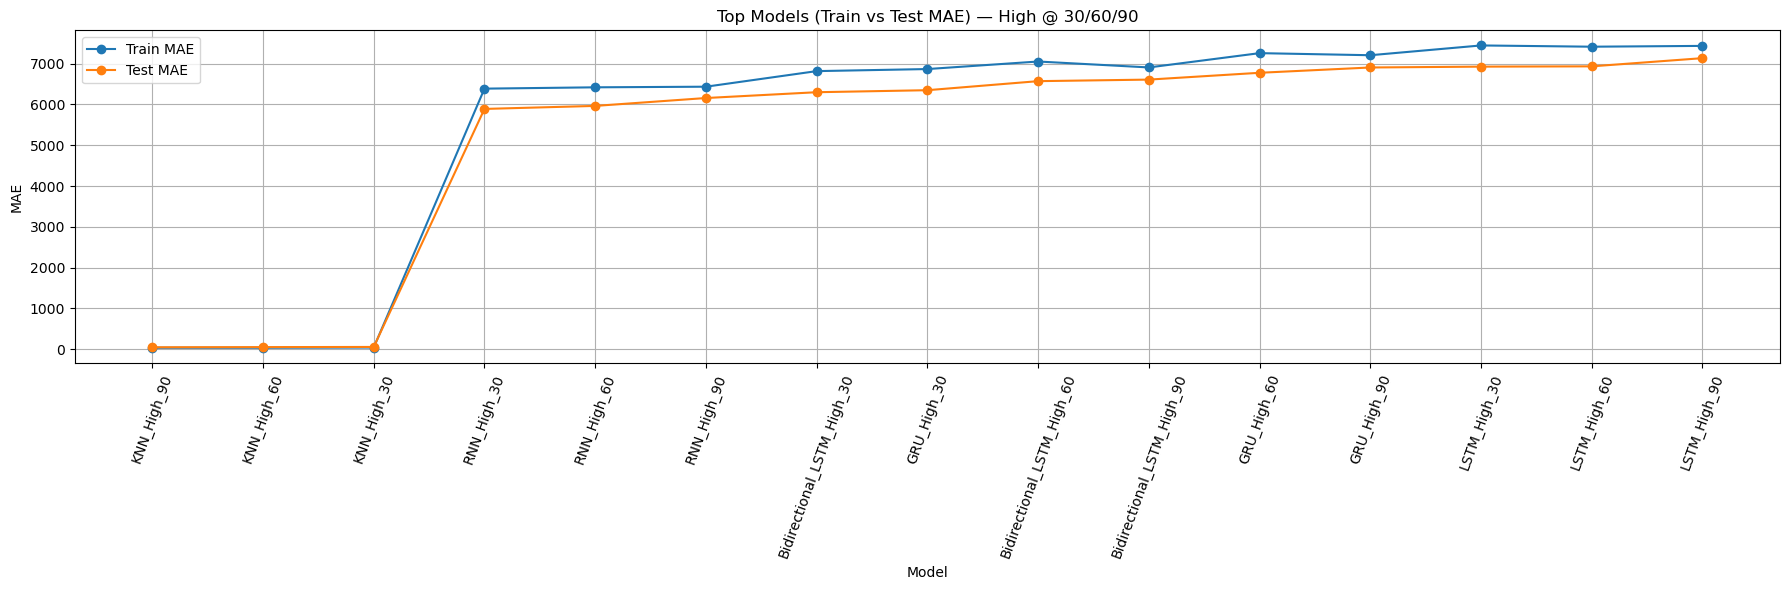

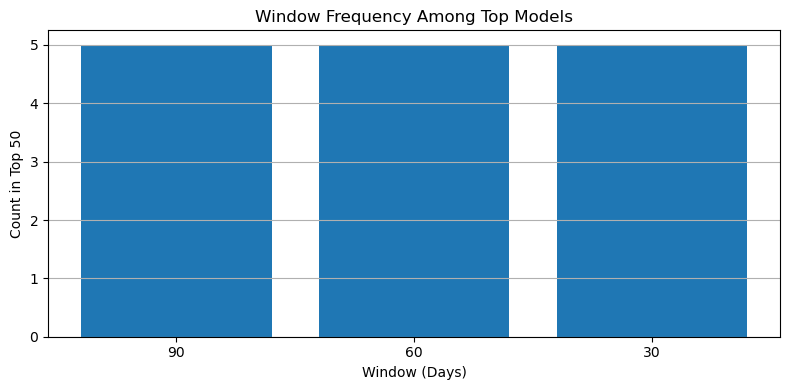

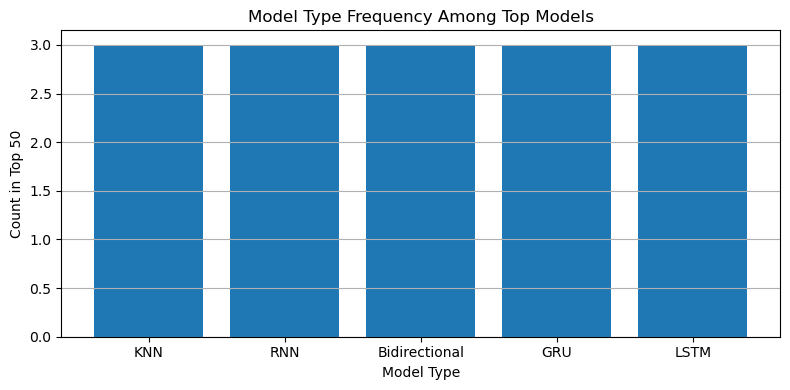

In [13]:

# 8. Plots (restricted scope already)
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)

plt.figure(figsize=(18, 6))
plt.plot(top_50['Model'], top_50['train_mae'], marker='o', label='Train MAE')
plt.plot(top_50['Model'], top_50['test_mae'],  marker='o', label='Test MAE')
plt.xticks(rotation=70)
plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Top Models (Train vs Test MAE) — High @ 30/60/90')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

# Window frequency
time_windows = pd.Series([m.split('_')[-1] for m in top_50['Model']]).value_counts().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(time_windows.index, time_windows.values)
plt.xlabel('Window (Days)'); plt.ylabel('Count in Top 50')
plt.title('Window Frequency Among Top Models'); plt.grid(axis='y'); plt.tight_layout()
plt.show()

# Model-type frequency
model_types = pd.Series([m.split('_')[0] for m in top_50['Model']]).value_counts().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(model_types.index, model_types.values)
plt.xlabel('Model Type'); plt.ylabel('Count in Top 50')
plt.title('Model Type Frequency Among Top Models'); plt.grid(axis='y'); plt.tight_layout()
plt.show()


In [14]:

# 9. Save artifacts (results CSV + one ML and one DL example model)
import joblib

results_csv = os.path.join(ART_RESULTS, "results_v1.csv")
results_df.to_csv(results_csv, index=False)
print("Saved results:", results_csv)

# Save example ML (KNN) model for the best window by test_mae
best_knn_key = next((k for k in results_df['Model'] if k.startswith("KNN_")), None)
if best_knn_key:
    ml_path = os.path.join(ART_MODELS_ML, f"{best_knn_key}_v1.joblib")
    joblib.dump(trained_models[best_knn_key]['model'], ml_path)
    print("Saved ML model:", ml_path)

# Save example DL model (first available) as Keras .h5
best_dl_key = next((k for k in results_df['Model'] if any(k.startswith(p) for p in ["RNN_", "GRU_", "LSTM_", "Bidirectional_LSTM_"])), None)
if best_dl_key:
    dl_path = os.path.join(ART_MODELS_DL, f"{best_dl_key}_ep{DL_EPOCHS}_v1.h5")
    trained_models[best_dl_key]['model'].save(dl_path)
    print("Saved DL model:", dl_path)


Saved results: ..\snippets\artifacts\results\results_v1.csv
Saved ML model: ..\snippets\artifacts\models\ml\KNN_High_90_v1.joblib
Saved DL model: ..\snippets\artifacts\models\dl\RNN_High_30_ep50_v1.h5


In [15]:

# 10. Inference demo (use KNN best model if available)
if best_knn_key:
    # Select any sample consistent with its window length
    w = int(best_knn_key.split('_')[-1])
    X_any = chunked_data[f"X_{ASSIGN_TARGET}_{w}"][5]  # 6th sample
    pred = trained_models[best_knn_key]['model'].predict([X_any])
    print("Sample window length:", w)
    print("Input[5][:5]:", X_any[:5], "...")
    print("Prediction:", float(pred[0]))


Sample window length: 90
Input[5][:5]: [1662.1  1639.9  1631.55 1671.15 1627.4 ] ...
Prediction: 1261.65
